## import

In [1]:
import numpy as np 
import pandas as pd
import random 
import os
from typing import Tuple, List
import time

# https://discuss.pytorch.org/t/how-to-enable-torch-use-cuda-dsa/202824/5
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ['TORCH_USE_CUDA_DSA'] = "1"
# https://discuss.pytorch.org/t/keep-getting-cuda-oom-error-with-pytorch-failing-to-allocate-all-free-memory/133896/10
# https://dev.to/shittu_olumide_/how-can-i-set-maxsplitsizemb-to-avoid-fragmentation-in-pytorch-37h9
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:64 "

from tqdm import tqdm
import torch
import copy
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
import torch_geometric
# from torch_geometric import seed_everything
from torch_geometric.data import Data, HeteroData
from torch_geometric.loader import NeighborLoader, ImbalancedSampler
import torch_geometric.transforms as T
import torch_geometric.utils as U
from torch_geometric.utils import coalesce
from torch_geometric.nn import summary, HeteroConv, GATv2Conv, SAGEConv, Linear
import pyg_lib
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score, f1_score, auc, precision_recall_fscore_support, matthews_corrcoef 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import tempfile
# edit the line below to specify specify tmp_directory
# tempfile.tempdir = ''

torch.multiprocessing.set_sharing_strategy('file_system')
# https://stackoverflow.com/questions/71642653/how-to-resolve-the-error-runtimeerror-received-0-items-of-ancdata
import resource
rlimit = resource.getrlimit(resource.RLIMIT_NOFILE)
resource.setrlimit(resource.RLIMIT_NOFILE, (4096, rlimit[1]))

print(f"numpy.__version__ = {np.__version__}")
print(f"pandas.__version__ = {pd.__version__}")
print(f"torch.__version__ = {torch.__version__}")
print(f"torch_geometric.__version__ = {torch_geometric.__version__}")
print(f"pyg_lib.__version__ = {pyg_lib.__version__}")

hyperparameters = {
    'gene_mode': 'degree',
    'node_mode' : 'degree', #'id' or 'degree' for abcm nodes_types
    'edge_features' : False, # True = those are the true edge_weights from my network
    'Heads' : 1, #2
    # 'conv_number' : 2, # 
    # 'conv_type': 'SAGE', # 
    'sage_aggr': 'sum', # 'sum', 'var'
    'sage_norm': True, # False
    'sage_project': False,
    'heteroconv_aggr' : 'sum', # 'cat', 'max'
    'heteroconv_aggr_1' : 'sum', # 'sum', 'cat', 'max'
    'heteroconv_aggr_2' : 'sum', # 'sum', 'cat', 'max'
    'heteroconv_aggr_3' : 'sum', # 'cat', 'max'
    # 'activation': 'relu', # 'relu', 'tanh'
    'hc_2_q' : 1, # hc_2 = int(i/hc_2_q)
    'hc_3_q': 1, # hc_3_q = int(i/hc_3_q)
    # 'size_of_batch': 32,
    'neighbors': 30, #30, 40, 50
    'disjoint_loader' : True, 
    'zero_out_batch_features': True,
    'epochs_to_train' : 500, #
    'min_epochs_to_train': 3,
    'patience': 10,
    'min_delta': 0.005,
    'auto_loop': False,
    'nodes_pairs_features': 'zeros', #
    'dnds_mode': 'sum',
    'type_to_return': 'torch', # 'numpy'
    'final_type': 'torch', # 'numpy'
    'remove_forbidden_value': True,
    'shuffle_train': True,
    'ana_edges': 'common', # 'all
    'string_threshold': 700, # confidence = {'low': 0.15, 'medium': 0.4, 'high': 0.7, 'highest': 0.9} from STRING doc, * 1000 to have EdgeScore
    'setting': 'nodes_to_nodes',
    'global_loader_neighbors': 'all' # neighbors
}


dict_j = {1:'01', 2:'02', 3:'03', 4:'04', 5:'05', 6:'06', 7:'07', 8:'08', 9:'09', 10:'10'}

sage_aggr = hyperparameters['sage_aggr'] # 'sum'
sage_norm = hyperparameters['sage_norm'] # 'sum'
heteroconv_aggr = hyperparameters['heteroconv_aggr'] #'sum', 'cat'
heteroconv_aggr_1 = hyperparameters['heteroconv_aggr_1'] #'sum', 'cat'
heteroconv_aggr_2 = hyperparameters['heteroconv_aggr_2'] #'sum', 'cat'
heteroconv_aggr_3 = hyperparameters['heteroconv_aggr_3'] #'sum', 'cat'
node_mode = hyperparameters['node_mode'] # 'id' or 'degree'
sage_norm = hyperparameters['sage_norm']
Heads = hyperparameters['Heads']
ana_edges = hyperparameters['ana_edges']
string_threshold = hyperparameters['string_threshold']
# conv_number = hyperparameters['conv_number']
setting = hyperparameters['setting']
# conv_type = hyperparameters['conv_type']
heads = hyperparameters['Heads']
# activation = hyperparameters['activation']
global_loader_neighbors = hyperparameters['global_loader_neighbors']


t0 = time.time()

old_path = os.getcwd()
new_path = old_path + '/../../'
os.chdir(new_path)
current_path = os.getcwd()
data_raw_path = current_path + '/data/raw/'
data_processed_path = current_path + '/data/processed/'

numpy.__version__ = 1.26.3
pandas.__version__ = 2.2.1
torch.__version__ = 2.1.2+cu118
torch_geometric.__version__ = 2.5.2
pyg_lib.__version__ = 0.3.1+pt21cu118


In [2]:
my_dict = {}

net = pd.read_csv(data_processed_path + f'yeast_knowledge_graph.tsv', sep = '\t', header = 0, dtype = {0: str, 1: str, 3: str, 4: str})

for string_threshold in [-1, 150, 400, 700, 900]:
    net = net.drop(net[(net['EdgeType'].isin(['PPI'])) & (net['EdgeScore'] < string_threshold)].index, axis = 0)
    net = net.reset_index(drop = True)
    all_genes = list(set().union(net[net['node1_type'] == 'GENE']['node1_ID'].unique(), net[net['node2_type'] == 'GENE']['node2_ID'].unique()))
    all_genes.sort()
    my_dict[string_threshold] = all_genes
    print(f"- For string_threshold: {string_threshold}, the number of GENES is: {len(all_genes)}")

- For string_threshold: -1, the number of GENES is: 6579
- For string_threshold: 150, the number of GENES is: 6579
- For string_threshold: 400, the number of GENES is: 6579
- For string_threshold: 700, the number of GENES is: 6579
- For string_threshold: 900, the number of GENES is: 6579


- For string_threshold: -1, the number of GENES is: 6579
- For string_threshold: 150, the number of GENES is: 6579
- For string_threshold: 400, the number of GENES is: 6579
- For string_threshold: 700, the number of GENES is: 6579
- For string_threshold: 900, the number of GENES is: 6579

In [4]:
# open the Yeasst_Knowledge_Graph
net = pd.read_csv(data_processed_path + f'yeast_knowledge_graph.tsv', sep = '\t', header = 0, dtype = {0:str, 1: str, 3: str, 4: str})
net = net.drop(net[(net['EdgeType'].isin(['PPI'])) & (net['EdgeScore'] < string_threshold)].index, axis = 0)
net = net.reset_index(drop = True)

all_genes = list(set().union(net[net['node1_type'] == 'GENE']['node1_ID'].unique(), net[net['node2_type'] == 'GENE']['node2_ID'].unique()))
# I could hardcode edges_names, edge_summary eveneutally
edges_names = net['EdgeType'].value_counts().to_dict()
edges_summary = []
for edge_name in edges_names.keys():
    tmp_list = [edge_name, 
                net[net['EdgeType'] == edge_name]['node1_type'].unique()[0], 
                net[net['EdgeType'] == edge_name]['node2_type'].unique()[0], 
                net[net['EdgeType'] == edge_name]['EdgeDirection'].unique()[0], 
                edges_names[edge_name]]
    # create a special case when there are edge_attributes
    # not currently using edges_attributes, but maybe in a future version 
    if sum(net[net['EdgeType'] == edge_name]['EdgeScore'].isna()) == 0:
        tmp_list.append(1)
    else:
        tmp_list.append(0)
    edges_summary.append(tmp_list) 

edges_types = list(set(net['EdgeType'].unique()))
nodes_types = list(set().union(net['node1_type'].unique(),net['node2_type'].unique()))
nodes_types.sort()
nodes_numbers = {}
for node_type in nodes_types:
    nodes_numbers[node_type] = len(set().union(net[net['node1_type'] == node_type]['node1_ID'].unique(), net[net['node2_type'] == node_type]['node2_ID'].unique()))

print(f"nodes_types: {nodes_types}")
print(f"nodes_numbers: {nodes_numbers}")

list_of_edges = net['EdgeType'].unique().tolist()

def Get_df_for_nodetype_id(df: pd.DataFrame, node_type : str) -> pd.DataFrame:
    node_type_list = list(set().union(df[df['node1_type'] == node_type]['node1_ID'].unique(), df[df['node2_type'] == node_type]['node2_ID'].unique()))
    node_type_list.sort()
    node_type_array = np.asarray(node_type_list)
    new_df = pd.DataFrame(data = {
        f"{node_type}_id": node_type_array,
        "mapped_id": pd.RangeIndex(len(node_type_array))
    })
    return(new_df)

nodes2id = {}
for type_of_node in nodes_types:
    nodes2id[type_of_node] = Get_df_for_nodetype_id(net, type_of_node)

edges_to_nodes = {}
for type_of_edge in edges_summary:
    edges_to_nodes[type_of_edge[0]] = [type_of_edge[1], type_of_edge[2]] 

nodes_types: ['BP', 'CC', 'GENE', 'MF']
nodes_numbers: {'BP': 27995, 'CC': 4040, 'GENE': 6579, 'MF': 11297}


## correlation matrix features and target

In [5]:
def get_target_tensor():
    # for nodes, essential vs non_essential
    essential = pd.read_csv(data_processed_path + 'yeast_essential_nonessential_20240612.tsv', sep = '\t', header = 0)
    nodes2id['GENE'] = nodes2id['GENE'][['GENE_id', 'mapped_id']]
    nodes = nodes2id['GENE'].copy()
    nodes = nodes.merge(essential, how = 'left', left_on = 'GENE_id', right_on = 'gene_id')
    nodes.loc[nodes[nodes['type'] == 'essential'].index, 'target'] = 1
    nodes.loc[nodes[nodes['type'] == 'non_essential'].index, 'target'] = 0
    target_tensor = torch.from_numpy(nodes['target'].values)
    return target_tensor 

In [6]:
target_tensor = get_target_tensor()
target = target_tensor.numpy()

### target = 'essential'

In [7]:
# create the gene features
feat_1000 = pd.read_csv('/data-cbl/rnicolle/GRL4DD/data/processed/yeast_features_1000_20240717.tsv', header = 0, sep = '\t')
yeast_features_to_use = [
    'dn_ds', 'chemical_compound_accumulation','chronological_lifespan', 'competitive_fitness',
    'desiccation_resistance', 'haploinsufficient', 'heat_sensitivity', 'metal_resistance', 
    'oxidative_stress_resistance', 'replicative_lifespan', 'resistance_to_chemicals', 'respiratory_growth',
    'stress_resistance', 'toxin_resistance', 'utilization_of_nitrogen_source', 'vacuolar_morphology', 'vegetative_growth']
feat = feat_1000[yeast_features_to_use]

In [8]:
feat.loc[:, ['y']] = target

In [9]:
feat.columns

Index(['dn_ds', 'chemical_compound_accumulation', 'chronological_lifespan',
       'competitive_fitness', 'desiccation_resistance', 'haploinsufficient',
       'heat_sensitivity', 'metal_resistance', 'oxidative_stress_resistance',
       'replicative_lifespan', 'resistance_to_chemicals', 'respiratory_growth',
       'stress_resistance', 'toxin_resistance',
       'utilization_of_nitrogen_source', 'vacuolar_morphology',
       'vegetative_growth', 'y'],
      dtype='object')

In [10]:
corr = feat.corr()
corr

,dn_ds,chemical_compound_accumulation,chronological_lifespan,competitive_fitness,desiccation_resistance,haploinsufficient,heat_sensitivity,metal_resistance,oxidative_stress_resistance,replicative_lifespan,resistance_to_chemicals,respiratory_growth,stress_resistance,toxin_resistance,utilization_of_nitrogen_source,vacuolar_morphology,vegetative_growth,y
dn_ds,1.000000,-0.039916,-0.054821,-0.022454,-0.046158,-0.069888,-0.081494,-0.049647,-0.041351,-0.038001,-0.087530,-0.069437,-0.004911,-0.072592,-0.017572,0.026490,-0.095152,-0.134314
chemical_compound_accumulation,-0.039916,1.000000,0.326587,0.246543,0.326530,-0.019811,0.231858,0.299485,0.358677,0.226397,0.234567,0.360699,0.331145,0.199757,0.266430,0.260803,0.327268,-0.279816
chronological_lifespan,-0.054821,0.326587,1.000000,0.209177,0.287243,-0.021568,0.186662,0.224348,0.283318,0.200709,0.177135,0.329524,0.235928,0.164315,0.225763,0.194820,0.242558,-0.180354
competitive_fitness,-0.022454,0.246543,0.209177,1.000000,0.168715,0.153173,0.196830,0.205662,0.218460,0.160045,0.626948,0.138329,0.210294,0.204907,0.163099,0.313304,0.183531,-0.062698
desiccation_resistance,-0.046158,0.326530,0.287243,0.168715,1.000000,0.012005,0.249548,0.229322,0.304401,0.146524,0.151257,0.419790,0.330902,0.206457,0.221979,0.163556,0.285189,-0.112565
haploinsufficient,-0.069888,-0.019811,-0.021568,0.153173,0.012005,1.000000,0.095443,-0.003790,0.006934,0.019728,0.206134,-0.015161,0.018846,0.099910,-0.023926,-0.048453,0.074450,0.324897
heat_sensitivity,-0.081494,0.231858,0.186662,0.196830,0.249548,0.095443,1.000000,0.180770,0.210071,0.119697,0.219167,0.276912,0.215234,0.233116,0.130212,0.106868,0.255813,0.052129
metal_resistance,-0.049647,0.299485,0.224348,0.205662,0.229322,-0.003790,0.180770,1.000000,0.275248,0.177355,0.194355,0.236232,0.278506,0.221056,0.160245,0.194819,0.280925,-0.147282
oxidative_stress_resistance,-0.041351,0.358677,0.283318,0.218460,0.304401,0.006934,0.210071,0.275248,1.000000,0.195079,0.201365,0.357071,0.314420,0.194439,0.189804,0.208529,0.279337,-0.167998
replicative_lifespan,-0.038001,0.226397,0.200709,0.160045,0.146524,0.019728,0.119697,0.177355,0.195079,1.000000,0.133148,0.169996,0.175738,0.141185,0.111014,0.114128,0.149769,-0.140326


<AxesSubplot:>

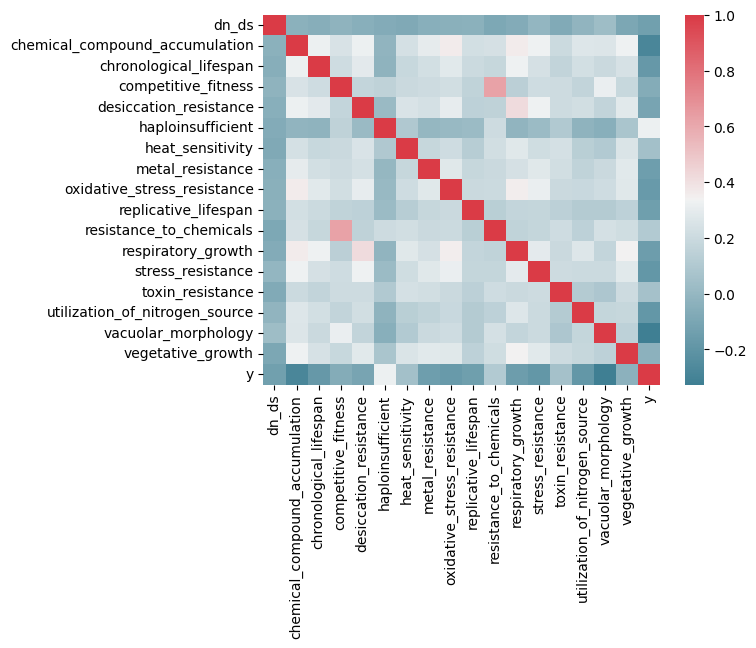

In [19]:
sns.heatmap(corr,
            cmap = sns.diverging_palette(220,10, as_cmap=True),
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values)

# n2n, seeds 30

### function target

In [11]:
def get_target_tensor():
    # for nodes, essential vs non_essential
    essential = pd.read_csv(data_processed_path + 'yeast_essential_nonessential_20240612.tsv', sep = '\t', header = 0)
    nodes2id['GENE'] = nodes2id['GENE'][['GENE_id', 'mapped_id']]
    nodes = nodes2id['GENE'].copy()
    nodes = nodes.merge(essential, how = 'left', left_on = 'GENE_id', right_on = 'gene_id')
    nodes.loc[nodes[nodes['type'] == 'essential'].index, 'target'] = 1
    nodes.loc[nodes[nodes['type'] == 'non_essential'].index, 'target'] = 0
    target_tensor = torch.from_numpy(nodes['target'].values)
    return target_tensor 

In [12]:
target = get_target_tensor()

In [13]:
target.sum()

tensor(1311., dtype=torch.float64)

In [14]:
feat

,dn_ds,chemical_compound_accumulation,chronological_lifespan,competitive_fitness,desiccation_resistance,haploinsufficient,heat_sensitivity,metal_resistance,oxidative_stress_resistance,replicative_lifespan,resistance_to_chemicals,respiratory_growth,stress_resistance,toxin_resistance,utilization_of_nitrogen_source,vacuolar_morphology,vegetative_growth,y
0,0.241627,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.455047,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
2,0.241627,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.156736,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.034369,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6574,0.216415,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
6575,0.241627,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6576,0.241627,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6577,0.241627,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## target = 'essential'

In [ ]:
# Create 30 train/test splits with a 70/30 ratio.
# Perform 10-fold cross_validation on each train set (= for each seed)

In [15]:
essential = pd.read_csv(data_processed_path + 'yeast_essential_nonessential_20240612.tsv', sep = '\t', header = 0)
nodes2id['GENE'] = nodes2id['GENE'][['GENE_id', 'mapped_id']]
nodes = nodes2id['GENE'].copy()
nodes = nodes.merge(essential, how = 'left', left_on = 'GENE_id', right_on = 'gene_id')
nodes.loc[nodes[nodes['type'] == 'essential'].index, 'target'] = 1
nodes.loc[nodes[nodes['type'] == 'non_essential'].index, 'target'] = 0

In [16]:
nodes['target'].value_counts()

target
0.0    5268
1.0    1311
Name: count, dtype: int64

In [17]:
nodes = nodes.drop('gene_id', axis = 1)

In [18]:
len(nodes)

6579

In [19]:
essential_index = nodes[nodes['type'] == 'essential'].index
non_essential_index = nodes[nodes['type'] == 'non_essential'].index

In [20]:
int(len(essential_index) * 0.70)

917

In [21]:
int(len(non_essential_index) * 0.70)

3687

## create_split_seed

In [22]:
def create_split_seed(df: pd.DataFrame, number: int = 0, train_ratio: float = 0.70) -> pd.Series:
    random.seed(number)
    name = f"seed_{number}"
    
    essential_index = list(nodes[nodes['type'] == 'essential'].index)
    non_essential_index = list(nodes[nodes['type'] == 'non_essential'].index)
    
    train_pos_selected = random.sample(essential_index, int(len(essential_index) * train_ratio))
    train_pos_selected.sort()
    train_neg_selected = random.sample(non_essential_index, int(len(non_essential_index) * train_ratio))
    train_neg_selected.sort()
    
    ser = pd.Series(data = ['test'] * len(df), name = name)
    ser.iloc[train_pos_selected] = 'train'
    ser.iloc[train_neg_selected] = 'train'
    
    return ser

In [23]:
splits_seeds = pd.concat([create_split_seed(df = nodes, number = i, train_ratio = 0.70) for i in range(1,31)], axis = 1)

In [24]:
splits_seeds

,seed_1,seed_2,seed_3,seed_4,seed_5,seed_6,seed_7,seed_8,seed_9,seed_10,...,seed_21,seed_22,seed_23,seed_24,seed_25,seed_26,seed_27,seed_28,seed_29,seed_30
0,train,test,test,train,train,train,train,train,train,test,...,test,test,train,train,test,train,train,train,train,train
1,test,train,train,test,train,train,test,train,train,test,...,test,test,test,test,train,test,train,train,test,train
2,test,train,train,train,train,train,train,test,train,train,...,test,train,train,train,train,test,train,train,train,train
3,test,test,train,train,test,train,test,train,test,train,...,train,train,train,train,train,train,train,test,train,train
4,train,train,train,train,test,test,train,train,train,train,...,train,train,train,test,train,train,train,test,train,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6574,train,test,train,train,test,test,train,train,train,train,...,test,test,train,train,train,train,train,train,train,train
6575,train,test,train,train,train,train,test,train,train,test,...,test,train,train,train,test,test,test,train,train,test
6576,train,train,train,train,train,train,train,train,train,train,...,train,train,train,train,train,train,train,test,train,train
6577,train,train,train,test,train,train,train,train,test,train,...,train,test,test,train,train,train,test,test,train,train


In [39]:
splits_seeds.to_csv(
    data_processed_path + 'yeasts_n2n_6579_splits_seeds.tsv',
    header = True, index = False, sep = '\t', mode = 'x')

In [25]:
splits_seeds = pd.read_csv(
    data_processed_path + 'yeasts_n2n_6579_splits_seeds.tsv',
    sep = '\t', header = 0
)

In [26]:
splits_seeds

,seed_1,seed_2,seed_3,seed_4,seed_5,seed_6,seed_7,seed_8,seed_9,seed_10,...,seed_21,seed_22,seed_23,seed_24,seed_25,seed_26,seed_27,seed_28,seed_29,seed_30
0,train,test,test,train,train,train,train,train,train,test,...,test,test,train,train,test,train,train,train,train,train
1,test,train,train,test,train,train,test,train,train,test,...,test,test,test,test,train,test,train,train,test,train
2,test,train,train,train,train,train,train,test,train,train,...,test,train,train,train,train,test,train,train,train,train
3,test,test,train,train,test,train,test,train,test,train,...,train,train,train,train,train,train,train,test,train,train
4,train,train,train,train,test,test,train,train,train,train,...,train,train,train,test,train,train,train,test,train,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6574,train,test,train,train,test,test,train,train,train,train,...,test,test,train,train,train,train,train,train,train,train
6575,train,test,train,train,train,train,test,train,train,test,...,test,train,train,train,test,test,test,train,train,test
6576,train,train,train,train,train,train,train,train,train,train,...,train,train,train,train,train,train,train,test,train,train
6577,train,train,train,test,train,train,train,train,test,train,...,train,test,test,train,train,train,test,test,train,train


In [27]:
pd.concat([nodes, splits_seeds['seed_1']], axis = 1)

,GENE_id,mapped_id,type,target,seed_1
0,YAL001C,0,essential,1.0,train
1,YAL002W,1,non_essential,0.0,test
2,YAL003W,2,essential,1.0,test
3,YAL004W,3,non_essential,0.0,test
4,YAL005C,4,non_essential,0.0,train
...,...,...,...,...,...
6574,YPR201W,6574,non_essential,0.0,train
6575,YPR202W,6575,non_essential,0.0,train
6576,YPR203W,6576,non_essential,0.0,train
6577,YPR204C-A,6577,non_essential,0.0,train


In [28]:
nodes = nodes[['GENE_id', 'mapped_id', 'type', 'target']]

In [29]:
nodes

,GENE_id,mapped_id,type,target
0,YAL001C,0,essential,1.0
1,YAL002W,1,non_essential,0.0
2,YAL003W,2,essential,1.0
3,YAL004W,3,non_essential,0.0
4,YAL005C,4,non_essential,0.0
...,...,...,...,...
6574,YPR201W,6574,non_essential,0.0
6575,YPR202W,6575,non_essential,0.0
6576,YPR203W,6576,non_essential,0.0
6577,YPR204C-A,6577,non_essential,0.0


In [30]:
def create_cross_val_for_split_seed(nodes: pd.DataFrame, split_seed: int = 1, number: int = 42) -> pd.Series:
    random.seed(number)
    col_to_use = f"seed_{split_seed}"
    splits_seeds = pd.read_csv(
        data_processed_path + 'yeasts_n2n_6579_splits_seeds.tsv',
        sep = '\t', header = 0
    )
    nodes = pd.concat([nodes, splits_seeds[col_to_use]], axis = 1)
    
    essential_index = list(nodes[(nodes['type'] == 'essential') & (nodes[col_to_use] == 'train')].index)
    non_essential_index = list(nodes[(nodes['type'] == 'non_essential') & (nodes[col_to_use] == 'train')].index)
    # https://stackoverflow.com/questions/3352737/how-to-randomly-partition-a-list-into-n-nearly-equal-parts
    essential_folds = [essential_index[i::10] for i in range(10)]
    non_essential_folds = [non_essential_index[i::10] for i in range(10)]
    
    ser = pd.Series(data = ['leave_out_test'] * len(nodes), name = f'cv_seed_{split_seed}')
    
    for i in range(len(essential_folds)):
        essential = essential_folds[i]
        essential.sort()
        non_essential = non_essential_folds[i]
        non_essential.sort()
        ser.iloc[essential] = f'cv_{i+1}'
        ser.iloc[non_essential] = f'cv_{i+1}'
    
    return ser

In [31]:
df = pd.concat([create_cross_val_for_split_seed(nodes = nodes, split_seed = i, number = 42) for i in range(1,31)], axis = 1)

In [32]:
df

,cv_seed_1,cv_seed_2,cv_seed_3,cv_seed_4,cv_seed_5,cv_seed_6,cv_seed_7,cv_seed_8,cv_seed_9,cv_seed_10,...,cv_seed_21,cv_seed_22,cv_seed_23,cv_seed_24,cv_seed_25,cv_seed_26,cv_seed_27,cv_seed_28,cv_seed_29,cv_seed_30
0,cv_1,leave_out_test,leave_out_test,cv_1,cv_1,cv_1,cv_1,cv_1,cv_1,leave_out_test,...,leave_out_test,leave_out_test,cv_1,cv_1,leave_out_test,cv_1,cv_1,cv_1,cv_1,cv_1
1,leave_out_test,cv_1,cv_1,leave_out_test,cv_1,cv_1,leave_out_test,cv_1,cv_1,leave_out_test,...,leave_out_test,leave_out_test,leave_out_test,leave_out_test,cv_1,leave_out_test,cv_1,cv_1,leave_out_test,cv_1
2,leave_out_test,cv_1,cv_1,cv_2,cv_2,cv_2,cv_2,leave_out_test,cv_2,cv_1,...,leave_out_test,cv_1,cv_2,cv_2,cv_1,leave_out_test,cv_2,cv_2,cv_2,cv_2
3,leave_out_test,leave_out_test,cv_2,cv_1,leave_out_test,cv_2,leave_out_test,cv_2,leave_out_test,cv_1,...,cv_1,cv_1,cv_1,cv_1,cv_2,cv_1,cv_2,leave_out_test,cv_1,cv_2
4,cv_1,cv_2,cv_3,cv_2,leave_out_test,leave_out_test,cv_1,cv_3,cv_2,cv_2,...,cv_2,cv_2,cv_2,leave_out_test,cv_3,cv_2,cv_3,leave_out_test,cv_2,leave_out_test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6574,cv_3,leave_out_test,cv_3,cv_4,leave_out_test,leave_out_test,cv_4,cv_3,cv_4,cv_4,...,leave_out_test,leave_out_test,cv_4,cv_3,cv_4,cv_4,cv_5,cv_5,cv_4,cv_4
6575,cv_4,leave_out_test,cv_4,cv_5,cv_4,cv_4,leave_out_test,cv_4,cv_5,leave_out_test,...,leave_out_test,cv_5,cv_5,cv_4,leave_out_test,leave_out_test,leave_out_test,cv_6,cv_5,leave_out_test
6576,cv_5,cv_5,cv_5,cv_6,cv_5,cv_5,cv_5,cv_5,cv_6,cv_5,...,cv_5,cv_6,cv_6,cv_5,cv_5,cv_5,cv_6,leave_out_test,cv_6,cv_5
6577,cv_6,cv_6,cv_6,leave_out_test,cv_6,cv_6,cv_6,cv_6,leave_out_test,cv_6,...,cv_6,leave_out_test,leave_out_test,cv_6,cv_6,cv_6,leave_out_test,leave_out_test,cv_7,cv_6


In [33]:
for i in range(1,31):
    print(i)
    print(df[f'cv_seed_{i}'].value_counts())
    print('xxx' * 20)

1
cv_seed_1
leave_out_test    1975
cv_1               461
cv_2               461
cv_3               461
cv_4               461
cv_5               461
cv_6               461
cv_7               461
cv_8               459
cv_9               459
cv_10              459
Name: count, dtype: int64
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
2
cv_seed_2
leave_out_test    1975
cv_1               461
cv_2               461
cv_3               461
cv_4               461
cv_5               461
cv_6               461
cv_7               461
cv_8               459
cv_9               459
cv_10              459
Name: count, dtype: int64
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
3
cv_seed_3
leave_out_test    1975
cv_1               461
cv_2               461
cv_3               461
cv_4               461
cv_5               461
cv_6               461
cv_7               461
cv_8               459
cv_9               459
cv_10              459
Name: count, dtype: int64
xxxxx

In [34]:
df

,cv_seed_1,cv_seed_2,cv_seed_3,cv_seed_4,cv_seed_5,cv_seed_6,cv_seed_7,cv_seed_8,cv_seed_9,cv_seed_10,...,cv_seed_21,cv_seed_22,cv_seed_23,cv_seed_24,cv_seed_25,cv_seed_26,cv_seed_27,cv_seed_28,cv_seed_29,cv_seed_30
0,cv_1,leave_out_test,leave_out_test,cv_1,cv_1,cv_1,cv_1,cv_1,cv_1,leave_out_test,...,leave_out_test,leave_out_test,cv_1,cv_1,leave_out_test,cv_1,cv_1,cv_1,cv_1,cv_1
1,leave_out_test,cv_1,cv_1,leave_out_test,cv_1,cv_1,leave_out_test,cv_1,cv_1,leave_out_test,...,leave_out_test,leave_out_test,leave_out_test,leave_out_test,cv_1,leave_out_test,cv_1,cv_1,leave_out_test,cv_1
2,leave_out_test,cv_1,cv_1,cv_2,cv_2,cv_2,cv_2,leave_out_test,cv_2,cv_1,...,leave_out_test,cv_1,cv_2,cv_2,cv_1,leave_out_test,cv_2,cv_2,cv_2,cv_2
3,leave_out_test,leave_out_test,cv_2,cv_1,leave_out_test,cv_2,leave_out_test,cv_2,leave_out_test,cv_1,...,cv_1,cv_1,cv_1,cv_1,cv_2,cv_1,cv_2,leave_out_test,cv_1,cv_2
4,cv_1,cv_2,cv_3,cv_2,leave_out_test,leave_out_test,cv_1,cv_3,cv_2,cv_2,...,cv_2,cv_2,cv_2,leave_out_test,cv_3,cv_2,cv_3,leave_out_test,cv_2,leave_out_test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6574,cv_3,leave_out_test,cv_3,cv_4,leave_out_test,leave_out_test,cv_4,cv_3,cv_4,cv_4,...,leave_out_test,leave_out_test,cv_4,cv_3,cv_4,cv_4,cv_5,cv_5,cv_4,cv_4
6575,cv_4,leave_out_test,cv_4,cv_5,cv_4,cv_4,leave_out_test,cv_4,cv_5,leave_out_test,...,leave_out_test,cv_5,cv_5,cv_4,leave_out_test,leave_out_test,leave_out_test,cv_6,cv_5,leave_out_test
6576,cv_5,cv_5,cv_5,cv_6,cv_5,cv_5,cv_5,cv_5,cv_6,cv_5,...,cv_5,cv_6,cv_6,cv_5,cv_5,cv_5,cv_6,leave_out_test,cv_6,cv_5
6577,cv_6,cv_6,cv_6,leave_out_test,cv_6,cv_6,cv_6,cv_6,leave_out_test,cv_6,...,cv_6,leave_out_test,leave_out_test,cv_6,cv_6,cv_6,leave_out_test,leave_out_test,cv_7,cv_6


In [35]:
df['cv_seed_1'].unique()

array(['cv_1', 'leave_out_test', 'cv_2', 'cv_3', 'cv_4', 'cv_5', 'cv_6',
       'cv_7', 'cv_8', 'cv_9', 'cv_10'], dtype=object)

In [55]:
df.to_csv(data_processed_path + 'yeasts_n2n_6579_splits_seeds_cv.tsv',
          sep = '\t', header = True, index = False, mode = 'x')

In [36]:
cv_folds = pd.read_csv(
        data_processed_path + 'yeasts_n2n_6579_splits_seeds_cv.tsv',
        sep = '\t', header = 0)

In [37]:
cv_folds

,cv_seed_1,cv_seed_2,cv_seed_3,cv_seed_4,cv_seed_5,cv_seed_6,cv_seed_7,cv_seed_8,cv_seed_9,cv_seed_10,...,cv_seed_21,cv_seed_22,cv_seed_23,cv_seed_24,cv_seed_25,cv_seed_26,cv_seed_27,cv_seed_28,cv_seed_29,cv_seed_30
0,cv_1,leave_out_test,leave_out_test,cv_1,cv_1,cv_1,cv_1,cv_1,cv_1,leave_out_test,...,leave_out_test,leave_out_test,cv_1,cv_1,leave_out_test,cv_1,cv_1,cv_1,cv_1,cv_1
1,leave_out_test,cv_1,cv_1,leave_out_test,cv_1,cv_1,leave_out_test,cv_1,cv_1,leave_out_test,...,leave_out_test,leave_out_test,leave_out_test,leave_out_test,cv_1,leave_out_test,cv_1,cv_1,leave_out_test,cv_1
2,leave_out_test,cv_1,cv_1,cv_2,cv_2,cv_2,cv_2,leave_out_test,cv_2,cv_1,...,leave_out_test,cv_1,cv_2,cv_2,cv_1,leave_out_test,cv_2,cv_2,cv_2,cv_2
3,leave_out_test,leave_out_test,cv_2,cv_1,leave_out_test,cv_2,leave_out_test,cv_2,leave_out_test,cv_1,...,cv_1,cv_1,cv_1,cv_1,cv_2,cv_1,cv_2,leave_out_test,cv_1,cv_2
4,cv_1,cv_2,cv_3,cv_2,leave_out_test,leave_out_test,cv_1,cv_3,cv_2,cv_2,...,cv_2,cv_2,cv_2,leave_out_test,cv_3,cv_2,cv_3,leave_out_test,cv_2,leave_out_test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6574,cv_3,leave_out_test,cv_3,cv_4,leave_out_test,leave_out_test,cv_4,cv_3,cv_4,cv_4,...,leave_out_test,leave_out_test,cv_4,cv_3,cv_4,cv_4,cv_5,cv_5,cv_4,cv_4
6575,cv_4,leave_out_test,cv_4,cv_5,cv_4,cv_4,leave_out_test,cv_4,cv_5,leave_out_test,...,leave_out_test,cv_5,cv_5,cv_4,leave_out_test,leave_out_test,leave_out_test,cv_6,cv_5,leave_out_test
6576,cv_5,cv_5,cv_5,cv_6,cv_5,cv_5,cv_5,cv_5,cv_6,cv_5,...,cv_5,cv_6,cv_6,cv_5,cv_5,cv_5,cv_6,leave_out_test,cv_6,cv_5
6577,cv_6,cv_6,cv_6,leave_out_test,cv_6,cv_6,cv_6,cv_6,leave_out_test,cv_6,...,cv_6,leave_out_test,leave_out_test,cv_6,cv_6,cv_6,leave_out_test,leave_out_test,cv_7,cv_6


In [38]:
tmp = cv_folds.transpose()

In [39]:
train_folds = ['cv_1', 'cv_2', 'cv_3', 'cv_4', 'cv_5', 'cv_6', 'cv_7', 'cv_8', 'cv_9', 'cv_10']

In [40]:
train_folds.remove('cv_1')

In [41]:
train_folds

['cv_2', 'cv_3', 'cv_4', 'cv_5', 'cv_6', 'cv_7', 'cv_8', 'cv_9', 'cv_10']

In [42]:
tmp = cv_folds[['cv_seed_1']]

In [43]:
tmp[tmp['cv_seed_1'].isin(train_folds)]

,cv_seed_1
5,cv_2
6,cv_3
7,cv_4
8,cv_5
9,cv_6
...,...
6574,cv_3
6575,cv_4
6576,cv_5
6577,cv_6


In [44]:
cv_folds[cv_folds['cv_seed_1'].isin(train_folds)]

,cv_seed_1,cv_seed_2,cv_seed_3,cv_seed_4,cv_seed_5,cv_seed_6,cv_seed_7,cv_seed_8,cv_seed_9,cv_seed_10,...,cv_seed_21,cv_seed_22,cv_seed_23,cv_seed_24,cv_seed_25,cv_seed_26,cv_seed_27,cv_seed_28,cv_seed_29,cv_seed_30
5,cv_2,cv_3,cv_4,cv_3,cv_2,cv_3,cv_2,cv_4,leave_out_test,leave_out_test,...,cv_3,cv_3,cv_3,leave_out_test,cv_4,leave_out_test,cv_4,leave_out_test,leave_out_test,leave_out_test
6,cv_3,cv_4,leave_out_test,cv_4,leave_out_test,cv_4,leave_out_test,cv_5,cv_3,cv_3,...,cv_4,cv_4,leave_out_test,leave_out_test,cv_5,cv_3,cv_5,cv_2,cv_3,leave_out_test
7,cv_4,cv_5,cv_5,cv_5,cv_3,cv_5,leave_out_test,cv_6,cv_4,leave_out_test,...,leave_out_test,cv_5,leave_out_test,cv_2,leave_out_test,cv_4,leave_out_test,cv_3,leave_out_test,cv_3
8,cv_5,leave_out_test,cv_6,leave_out_test,leave_out_test,cv_6,leave_out_test,cv_7,cv_5,cv_4,...,cv_5,cv_6,cv_4,cv_3,cv_6,cv_5,cv_6,cv_4,cv_4,cv_4
9,cv_6,leave_out_test,leave_out_test,cv_6,leave_out_test,cv_7,cv_3,cv_8,leave_out_test,leave_out_test,...,leave_out_test,cv_7,cv_5,leave_out_test,leave_out_test,cv_6,leave_out_test,cv_5,cv_5,cv_5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6574,cv_3,leave_out_test,cv_3,cv_4,leave_out_test,leave_out_test,cv_4,cv_3,cv_4,cv_4,...,leave_out_test,leave_out_test,cv_4,cv_3,cv_4,cv_4,cv_5,cv_5,cv_4,cv_4
6575,cv_4,leave_out_test,cv_4,cv_5,cv_4,cv_4,leave_out_test,cv_4,cv_5,leave_out_test,...,leave_out_test,cv_5,cv_5,cv_4,leave_out_test,leave_out_test,leave_out_test,cv_6,cv_5,leave_out_test
6576,cv_5,cv_5,cv_5,cv_6,cv_5,cv_5,cv_5,cv_5,cv_6,cv_5,...,cv_5,cv_6,cv_6,cv_5,cv_5,cv_5,cv_6,leave_out_test,cv_6,cv_5
6577,cv_6,cv_6,cv_6,leave_out_test,cv_6,cv_6,cv_6,cv_6,leave_out_test,cv_6,...,cv_6,leave_out_test,leave_out_test,cv_6,cv_6,cv_6,leave_out_test,leave_out_test,cv_7,cv_6


In [45]:
yeast_genes = pd.read_csv(data_processed_path + 'yeast_essential_nonessential_20240612.tsv', header = 0, sep = '\t')

In [46]:
yeast_genes

,gene_id,type
0,YAL001C,essential
1,YAL002W,non_essential
2,YAL003W,essential
3,YAL004W,non_essential
4,YAL005C,non_essential
...,...,...
6574,YPR201W,non_essential
6575,YPR202W,non_essential
6576,YPR203W,non_essential
6577,YPR204C-A,non_essential


In [ ]:
## attention, pour chaque seed = 70% train set et 30% leave out test set
# for each train set -> cross_validation. However the score for the leave_out test is always computed = do not take it into account 

# end